In [1]:
import numpy as np                        # Μαθηματική/αριθμητική βιβλιοθήκη
import matplotlib.pyplot as plt           # Βιβλιοθήκη απεικονίσεων
%matplotlib inline

## Άσκηση - Απόκριση Μηδενικής Κατάστασης (Zero-State Response)

Πριν ξεκινήσετε, είναι καλή ιδέα να δείτε την άσκηση $\texttt{Ex-ZeroInputResponse}$, όπου μελετήσαμε την **απόκριση μηδενικής εισόδου** (ZIR): αυτή που οφείλεται μόνο στις αρχικές συνθήκες, με $x(t)=0$. 

Εδώ θα συζητήσουμε για το **άλλο** κομμάτι της συνολικής απόκρισης, την **απόκριση μηδενικής κατάστασης** (zero-state response, ZSR).

Θυμηθείτε τη διάσπαση:

$$ y(t) = \underbrace{y_{zi}(t)}_{\text{μηδενικής εισόδου}} + \underbrace{y_{zs}(t)}_{\text{μηδενικής κατάστασης}} $$

Η απόκριση μηδενικής κατάστασης οφείλεται **αποκλειστικά στην είσοδο** $x(t)$, με **μηδενικές αρχικές συνθήκες** ($y(0)=0,\ \dot y(0)=0$ - το σύστημα ξεκινά «άδειο», χωρίς αποθηκευμένη ενέργεια). Είναι ακριβώς αυτό που περιγράφει η **κρουστική απόκριση** και η πράξη της **συνέλιξης**: όταν οι αρχικές συνθήκες είναι μηδενικές, η έξοδος εξαρτάται μόνο από την είσοδο (και την κρουστική απόκριση του συστήματος).

Χρησιμοποιούμε το **ίδιο** σύστημα δεύτερης τάξης με την άσκηση $\texttt{Ex-ZeroInputResponse}$ (κύκλωμα $RLC$ ή μάζα–ελατήριο–αποσβεστήρας), ώστε να δούμε το άλλο σκέλος της διάσπασης:

$$ \frac{d^2 y(t)}{dt^2} + 2\zeta\omega_n \frac{dy(t)}{dt} + \omega_n^2\, y(t) = \omega_n^2\, x(t) $$

με $\omega_n = 4$ rad/s και $\zeta=0.25$ (υπο-αποσβεσμένο), δηλαδή

$$ \frac{d^2 y}{dt^2} + 2\frac{dy}{dt} + 16\, y = 16\, x(t) $$

Τώρα όμως θέτουμε **μηδενικές** αρχικές συνθήκες $y(0)=0,\ \dot y(0)=0$ και δίνουμε ως είσοδο τη γνωστή μας **βηματική** συνάρτηση $x(t)=u(t)$ (αν και μπορούμε να βάλουμε οποιοδήποτε άλλο). Το αποτέλεσμα είναι η γνωστή **βηματική απόκριση** ενός υπο-αποσβεσμένου συστήματος (με χαρακτηριστική υπερύψωση/overshoot πριν σταθεροποιηθεί).

Όπως και στις υπόλοιπες ασκήσεις του Κεφαλαίου, γράφουμε τη δεύτερης τάξης εξίσωση ως σύστημα δύο εξισώσεων πρώτης τάξης με μεταβλητές κατάστασης $y_1=y$, $y_2=\dot y$ και εφαρμόζουμε τη μέθοδο του Euler:

\begin{align}
    y_1(n+1) &= y_1(n) + T_s\, y_2(n) \\
    y_2(n+1) &= y_2(n) + T_s\left(-\omega_n^2\, y_1(n) - 2\zeta\omega_n\, y_2(n) + \omega_n^2\, x(n)\right)
\end{align}

Η μόνη διαφορά από την άσκηση της ZIR είναι στα «δεδομένα» του προβλήματος: έχουμε πλέον **μηδενικές αρχικές συνθήκες** ($y_1(0)=y_2(0)=0$) αλλά **μη μηδενική είσοδος** ($x(n)=1$). Αυτό ακριβώς είναι το νόημα της «μηδενικής κατάστασης».

Σας δίνεται ότι, για είσοδο $x(t)=u(t)$ και μηδενικές αρχικές συνθήκες, η θεωρητική απόκριση μηδενικής κατάστασης του υπο-αποσβεσμένου συστήματος είναι:

$$ y_{zs}(t) = \left(1 - e^{-\sigma t}\left[\cos(\omega_d t) + \frac{\sigma}{\omega_d}\sin(\omega_d t)\right]\right) u(t) $$

όπου $\sigma=\zeta\omega_n=1$ και $\omega_d=\omega_n\sqrt{1-\zeta^2}\approx 3.873$ rad/s. Παρατηρήστε ότι $y_{zs}(t)\to 1$ καθώς $t\to\infty$, με φθίνουσα ταλάντωση γύρω από τη μονάδα στην πορεία.

Ακολουθεί ο κώδικας για $T_s=0.1$ s.

In [6]:
Ts = 0.1                                  # Περίοδος δειγματοληψίας
t  = np.arange(start=0, stop=5, step=Ts)  # Διάνυσμα χρόνου t

# --- Παράμετροι συστήματος (ίδιο σύστημα με την ZIR) ---
wn    = 4.0                               # φυσική συχνότητα ω_n
zeta  = 0.25                              # συντελεστής απόσβεσης ζ
sigma = zeta*wn                           # ρυθμός απόσβεσης σ = ζω_n
wd    = wn*np.sqrt(1 - zeta**2)           # αποσβεσμένη συχνότητα ω_d

# --- Αρχικές συνθήκες: ΜΗΔΕΝΙΚΕΣ (zero-state) ---
y0 = 0.0                                  # y(0)  = 0
v0 = 0.0                                  # y'(0) = 0

# --- Είσοδος: βηματική x(t) = u(t) ---
x = np.ones(len(t))                       # u(t) (προσεγγιστικά, για 5 s)

# --- Θεωρητική απόκριση μηδενικής κατάστασης ---
y_theory = 1 - np.exp(-sigma*t)*(np.cos(wd*t) + (sigma/wd)*np.sin(wd*t))

# --- Προσεγγιστική λύση (Euler με 2 μεταβλητές κατάστασης) ---
y1 = np.zeros(len(t))                     # y1 = y   (θέση)
y2 = np.zeros(len(t))                     # y2 = y'  (ταχύτητα)

y1[0] = y0                                # Μηδενική αρχική θέση
y2[0] = v0                                # Μηδενική αρχική ταχύτητα
for n in range(0, len(t)-1):              # For loop - ζεύγος αναδρομικών σχέσεων
    y1[n+1] = y1[n] + Ts*y2[n]
    y2[n+1] = y2[n] + Ts*(-wn**2*y1[n] - 2*zeta*wn*y2[n] + wn**2*x[n])

y = y1                                    # Η έξοδός μας είναι η μεταβλητή θέσης

Απεικονίζουμε το **απόλυτο** σφάλμα $|y-y_{true}|$.

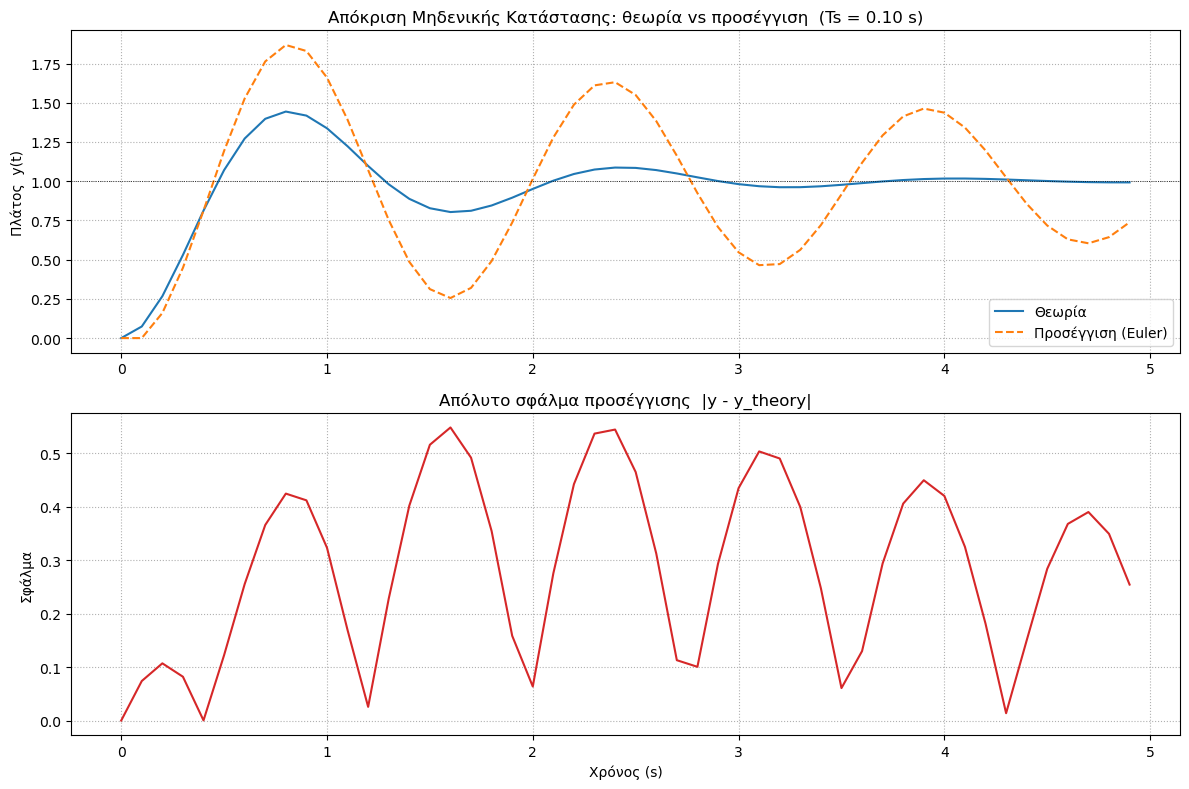

In [ ]:
# Γραφήματα
plt.figure(figsize = (12,8))
plt.subplot(2, 1, 1)
plt.plot(t, y_theory, '-',  label="Θεωρία")
plt.plot(t, y,        '--', label="Προσέγγιση (Euler)")
plt.axhline(1, color='k', linewidth=0.6, linestyle=':')   # τελική τιμή (DC gain)
plt.grid(linestyle=':')
plt.title('Απόκριση Μηδενικής Κατάστασης: θεωρία vs προσέγγιση  (Ts = %.2f s)' % Ts)
plt.ylabel('Πλάτος  y(t)')
plt.legend(loc='lower right')

err_abs = np.abs(y - y_theory)
plt.subplot(2, 1, 2)
plt.plot(t, err_abs, color='tab:red')
plt.grid(linestyle=':')
plt.title('Απόλυτο σφάλμα προσέγγισης |y - y_theory|')
plt.xlabel('Χρόνος (s)')
plt.ylabel('Σφάλμα')
plt.tight_layout()
plt.show()

Επαναλάβετε το παραπάνω για $T_s = 0.01$ s και τυπώστε τα αντίστοιχα γραφήματα.

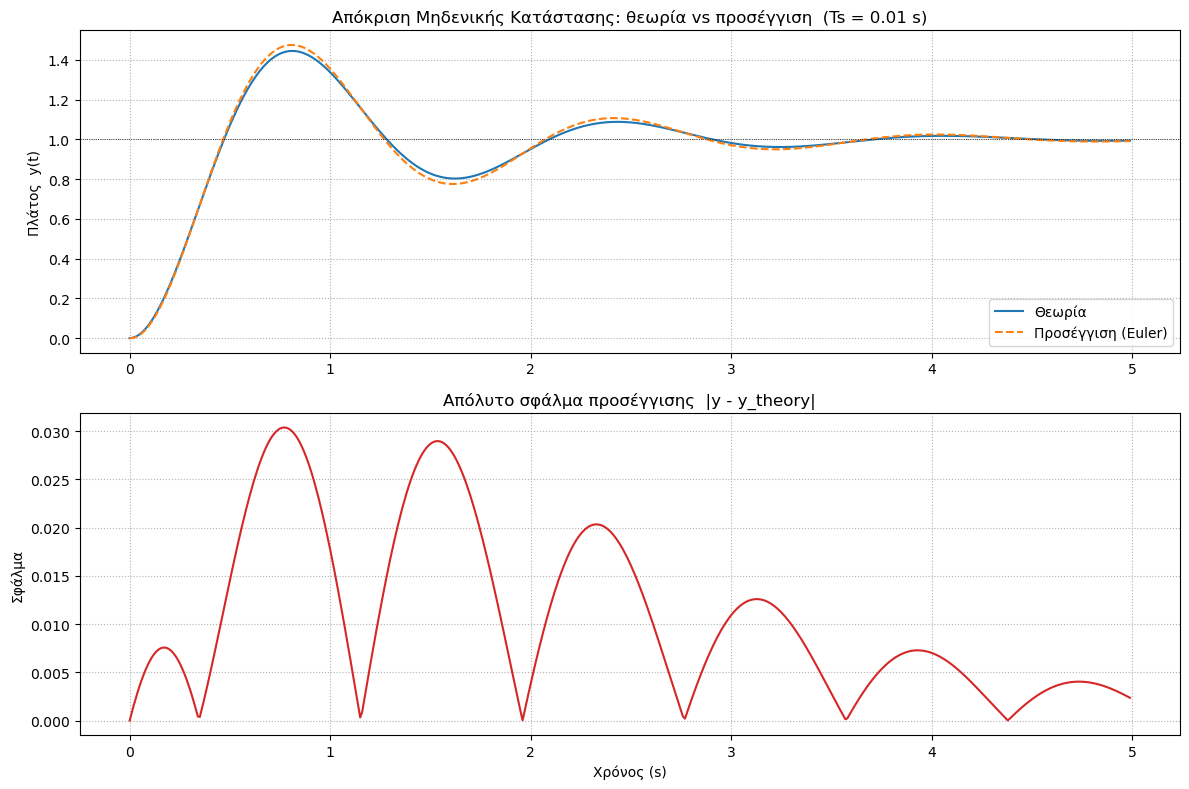

In [4]:
# INSERT CODE HERE
Ts = 0.01                                 # Περίοδος δειγματοληψίας
t  = np.arange(start=0, stop=5, step=Ts)  # Διάνυσμα χρόνου t

wn    = 4.0
zeta  = 0.25
sigma = zeta*wn
wd    = wn*np.sqrt(1 - zeta**2)

y0 = 0.0                                  # ΜΗΔΕΝΙΚΕΣ αρχικές συνθήκες
v0 = 0.0
x  = np.ones(len(t))                      # βηματική είσοδος u(t)

y_theory = 1 - np.exp(-sigma*t)*(np.cos(wd*t) + (sigma/wd)*np.sin(wd*t))

y1 = np.zeros(len(t)); y2 = np.zeros(len(t))
y1[0] = y0; y2[0] = v0
for n in range(0, len(t)-1):
    y1[n+1] = y1[n] + Ts*y2[n]
    y2[n+1] = y2[n] + Ts*(-wn**2*y1[n] - 2*zeta*wn*y2[n] + wn**2*x[n])
y = y1

# Γραφήματα
plt.figure(figsize = (12,8))
plt.subplot(2, 1, 1)
plt.plot(t, y_theory, '-',  label="Θεωρία")
plt.plot(t, y,        '--', label="Προσέγγιση (Euler)")
plt.axhline(1, color='k', linewidth=0.6, linestyle=':')
plt.grid(linestyle=':')
plt.title('Απόκριση Μηδενικής Κατάστασης: θεωρία vs προσέγγιση  (Ts = %.2f s)' % Ts)
plt.ylabel('Πλάτος  y(t)')
plt.legend(loc='lower right')

err_abs = np.abs(y - y_theory)
plt.subplot(2, 1, 2)
plt.plot(t, err_abs, color='tab:red')
plt.grid(linestyle=':')
plt.title('Απόλυτο σφάλμα προσέγγισης  |y - y_theory|')
plt.xlabel('Χρόνος (s)')
plt.ylabel('Σφάλμα')
plt.tight_layout()
plt.show()
# END OF CODE

Τι παρατηρείτε για την προσέγγιση για τις δύο τιμές του $T_s$; Πώς σχετίζεται αυτή η απόκριση με την απόκριση μηδενικής εισόδου της άσκησης $\texttt{Ex-ZeroInputResponse}$; Γράψτε την απάντησή σας σε αυτό το κελί:

### Απάντηση:

Όπως και στην ZIR, για $T_s=0.1$ s η προσέγγιση Euler έχει ορατό σφάλμα πλάτους, ενώ για $T_s=0.01$ s η προσέγγιση σχεδόν ταυτίζεται με τη θεωρία (μέγιστο σφάλμα ~0.55 → ~0.03). Και εδώ, η **μόνιμη** κατάσταση προσεγγίζεται σωστά.

Σχέση με τη ZIR: η **συνολική** απόκριση για μη μηδενικές αρχικές συνθήκες **και** μη μηδενική είσοδο είναι το άθροισμα των δύο,
$$ y(t) = y_{zi}(t) + y_{zs}(t). $$
Παρατηρήστε ότι και οι δύο αποκρίσεις μοιράζονται τους **ίδιους φυσικούς τρόπους** (natural modes) - την ίδια φθίνουσα ταλάντωση $e^{-\sigma t}\{\cos\omega_d t,\ \sin\omega_d t\}$ - γι' αυτό και το σφάλμα του Euler είναι πρακτικά το ίδιο στα δύο πειράματα. Η ZSR απλώς προσθέτει και το σταθερό όρο που επιβάλλει η είσοδος.

---
---